<a href="https://colab.research.google.com/github/depaimonn/UTS-NLP/blob/main/UTS_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
!pip install gensim wordcloud

In [25]:
# Import library standar NLP dan Data Science
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Library untuk Machine Learning & Representasi Teks
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from gensim.models import Word2Vec

# Library untuk visualisasi
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter

# Download modul NLTK yang dibutuhkan (termasuk punkt_tab yang sebelumnya error)
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [26]:
# Load dataset
df = pd.read_csv('mobile_legends_reviews.csv')

# Membuat label sentimen berdasarkan kolom 'score'
df['sentiment'] = df['score'].apply(lambda x: 1 if x >= 4 else 0)

# Mengambil sampel acak sebanyak 5000 dokumen agar proses training tidak terlalu lama
# Parameter random_state agar hasil bisa direproduksi (reproducible)
df_sample = df.sample(n=5000, random_state=42).reset_index(drop=True)

# Menampilkan distribusi sentimen
print("Distribusi Sentimen:\n", df_sample['sentiment'].value_counts())
df_sample[['content', 'score', 'sentiment']].head()

Distribusi Sentimen:
 sentiment
1    2586
0    2414
Name: count, dtype: int64


,content,score,sentiment
0,It's so unfair like bro I'm epic 1 then my tea...,1,0
1,I enjoy playing this game,5,1
2,This game is very instrintist but one problem ...,5,1
3,pls do not continue the revamped freya.,5,1
4,Fix harus download,5,1


In [27]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # 1. Cleaning & Case Folding
    text = re.sub(r'[^a-zA-Z\s]', '', str(text))
    text = text.lower()

    # 2. Tokenization
    tokens = word_tokenize(text)

    # 3. Stopword Removal & 4. Lemmatization
    processed_tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words and len(word) > 1
    ]

    return processed_tokens

# Terapkan fungsi ke dataset
df_sample['tokens'] = df_sample['content'].apply(preprocess_text)
# Gabungkan token kembali menjadi string untuk metode TF-IDF
df_sample['cleaned_text'] = df_sample['tokens'].apply(lambda x: ' '.join(x))

df_sample[['content', 'cleaned_text', 'tokens']].head()

,content,cleaned_text,tokens
0,It's so unfair like bro I'm epic 1 then my tea...,unfair like bro im epic teammate epic like wha...,"[unfair, like, bro, im, epic, teammate, epic, ..."
1,I enjoy playing this game,enjoy playing game,"[enjoy, playing, game]"
2,This game is very instrintist but one problem ...,game instrintist one problem u reset time,"[game, instrintist, one, problem, u, reset, time]"
3,pls do not continue the revamped freya.,pls continue revamped freya,"[pls, continue, revamped, freya]"
4,Fix harus download,fix harus download,"[fix, harus, download]"


In [29]:
X = df_sample['cleaned_text']
y = df_sample['sentiment']
X_tokens = df_sample['tokens']

# Split data
X_train_str, X_test_str, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_tok, X_test_tok, _, _ = train_test_split(X_tokens, y, test_size=0.2, random_state=42)

# --- METODE 1: TF-IDF ---
tfidf_vec = TfidfVectorizer(max_features=2000)
X_train_tfidf = tfidf_vec.fit_transform(X_train_str)
X_test_tfidf = tfidf_vec.transform(X_test_str)

# --- METODE 2: WORD2VEC ---
# Melatih model Word2Vec dari awal menggunakan token dari data latih
w2v_model = Word2Vec(sentences=X_train_tok, vector_size=100, window=5, min_count=2, workers=4)

# Fungsi untuk mendapatkan rata-rata vektor kata dalam satu kalimat (document vector)
def get_average_word2vec(tokens, model, vector_size):
    valid_words = [word for word in tokens if word in model.wv.key_to_index]
    if not valid_words:
        return np.zeros(vector_size)
    return np.mean(model.wv[valid_words], axis=0)

X_train_w2v = np.array([get_average_word2vec(tok, w2v_model, 100) for tok in X_train_tok])
X_test_w2v = np.array([get_average_word2vec(tok, w2v_model, 100) for tok in X_test_tok])

print("Shape TF-IDF Train:", X_train_tfidf.shape)
print("Shape Word2Vec Train:", X_train_w2v.shape)

Shape TF-IDF Train: (4000, 2000)
Shape Word2Vec Train: (4000, 100)


In [21]:
# Training Model TF-IDF
clf_tfidf = LogisticRegression(max_iter=1000)
clf_tfidf.fit(X_train_tfidf, y_train)
y_pred_tfidf = clf_tfidf.predict(X_test_tfidf)

# Training Model Word2Vec
clf_w2v = LogisticRegression(max_iter=1000)
clf_w2v.fit(X_train_w2v, y_train)
y_pred_w2v = clf_w2v.predict(X_test_w2v)

# Evaluasi
print("=== PERFORMA MODEL TF-IDF ===")
print("Akurasi TF-IDF:", accuracy_score(y_test, y_pred_tfidf))
print(classification_report(y_test, y_pred_tfidf))

print("\n=== PERFORMA MODEL WORD2VEC ===")
print("Akurasi Word2Vec:", accuracy_score(y_test, y_pred_w2v))
print(classification_report(y_test, y_pred_w2v))

=== PERFORMA MODEL TF-IDF ===
Akurasi TF-IDF: 0.873
              precision    recall  f1-score   support

           0       0.85      0.91      0.88       500
           1       0.90      0.83      0.87       500

    accuracy                           0.87      1000
   macro avg       0.88      0.87      0.87      1000
weighted avg       0.88      0.87      0.87      1000


=== PERFORMA MODEL WORD2VEC ===
Akurasi Word2Vec: 0.804
              precision    recall  f1-score   support

           0       0.82      0.78      0.80       500
           1       0.79      0.83      0.81       500

    accuracy                           0.80      1000
   macro avg       0.80      0.80      0.80      1000
weighted avg       0.80      0.80      0.80      1000



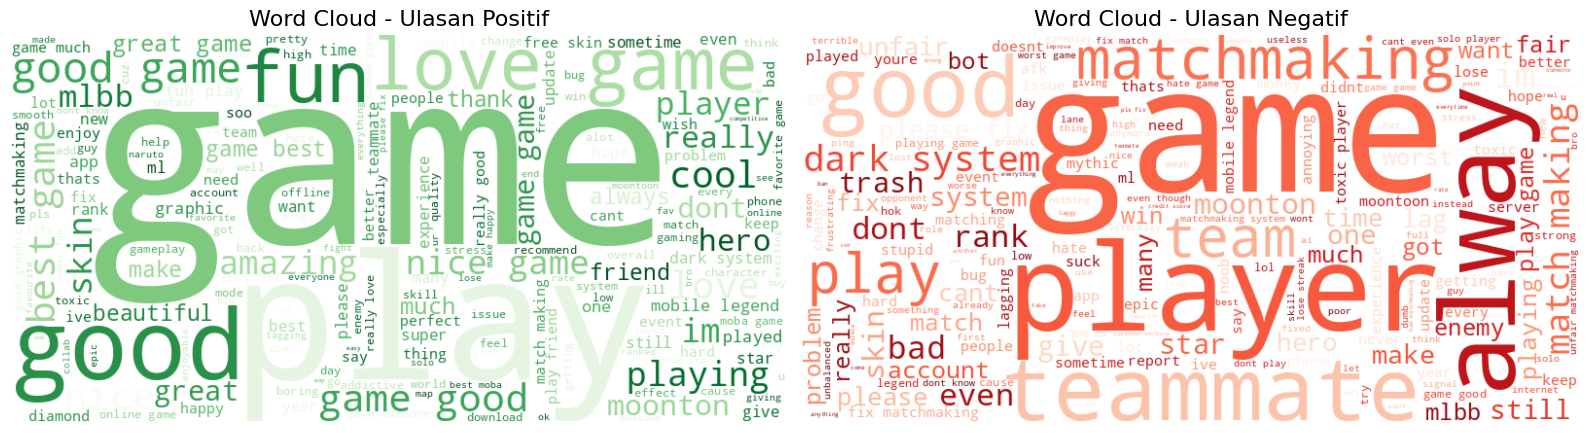

In [22]:
# Memisahkan teks positif dan negatif
positive_text = ' '.join(df_sample[df_sample['sentiment'] == 1]['cleaned_text'])
negative_text = ' '.join(df_sample[df_sample['sentiment'] == 0]['cleaned_text'])

# Setup matplotlib
fig, ax = plt.subplots(1, 2, figsize=(16, 8))

# WordCloud Positif
wc_pos = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(positive_text)
ax[0].imshow(wc_pos, interpolation='bilinear')
ax[0].set_title('Word Cloud - Ulasan Positif', fontsize=16)
ax[0].axis('off')

# WordCloud Negatif
wc_neg = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(negative_text)
ax[1].imshow(wc_neg, interpolation='bilinear')
ax[1].set_title('Word Cloud - Ulasan Negatif', fontsize=16)
ax[1].axis('off')

plt.tight_layout()
plt.show()

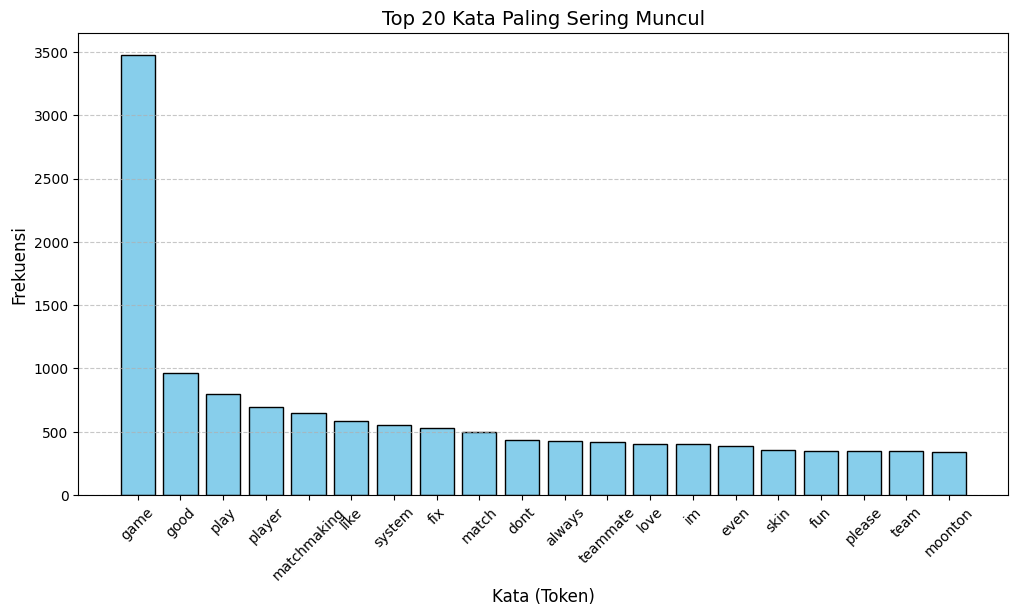

In [23]:
# Mengumpulkan semua token dari dataset
all_tokens = [word for tokens in df_sample['tokens'] for word in tokens]

# Menghitung frekuensi
word_freq = Counter(all_tokens)
top_20_words = dict(word_freq.most_common(20))

# Plot Bar Chart
plt.figure(figsize=(12, 6))
plt.bar(top_20_words.keys(), top_20_words.values(), color='skyblue', edgecolor='black')
plt.title('Top 20 Kata Paling Sering Muncul', fontsize=14)
plt.xlabel('Kata (Token)', fontsize=12)
plt.ylabel('Frekuensi', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()